# Naive Bayes implementation for Amazon Appliances sentiment analysis

In [7]:
import json
import gzip
import os
import warnings
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [8]:
# Notebook settings and output folder
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Create output folder for figures and exported files
os.makedirs("outputs", exist_ok=True)

# Display options for easier inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [9]:
# Download nltk resources
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [10]:
# Load the full appliances dataset

from pathlib import Path

# Get the directory of the current notebook/script
SCRIPT_DIR = Path().resolve().parent
DATA_PATH = SCRIPT_DIR.parent / "data" / "Appliances_5.json.gz"

def load_amazon_gz(path):
    """Load a gzipped JSON-lines Amazon review file into a DataFrame."""
    records = []
    with gzip.open(path, "rb") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

df_full = load_amazon_gz(DATA_PATH)

print(f"Full dataset loaded successfully.")
print(f"Shape: {df_full.shape[0]} reviews, {df_full.shape[1]} columns")
print(f"Columns:\n{df_full.columns.tolist()}")

Full dataset loaded successfully.
Shape: 2277 reviews, 12 columns
Columns:
['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']


In [11]:
# Label the data and select a stratified subset

def label_sentiment(rating):
    """Map Amazon star ratings to sentiment labels."""
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df_full["sentiment"] = df_full["overall"].apply(label_sentiment)

# Minimum required is 2000. We choose the total available for better training stability.
TARGET_SUBSET_SIZE = 2277

if len(df_full) > TARGET_SUBSET_SIZE:
    _, df_phase2 = train_test_split(
        df_full,
        train_size=TARGET_SUBSET_SIZE,
        stratify=df_full["overall"],
        random_state=42,
    )
else:
    df_phase2 = df_full.copy()

df_phase2 = df_phase2.reset_index(drop=True)

print(f"Phase 2 subset shape: {df_phase2.shape}")
print("\nRating distribution in subset:")
print(df_phase2["overall"].value_counts().sort_index())

print("\nSentiment distribution in subset:")
print(df_phase2["sentiment"].value_counts())

Phase 2 subset shape: (2277, 13)

Rating distribution in subset:
overall
1.0       9
2.0      13
3.0     421
4.0     222
5.0    1612
Name: count, dtype: int64

Sentiment distribution in subset:
sentiment
Positive    1834
Neutral      421
Negative      22
Name: count, dtype: int64


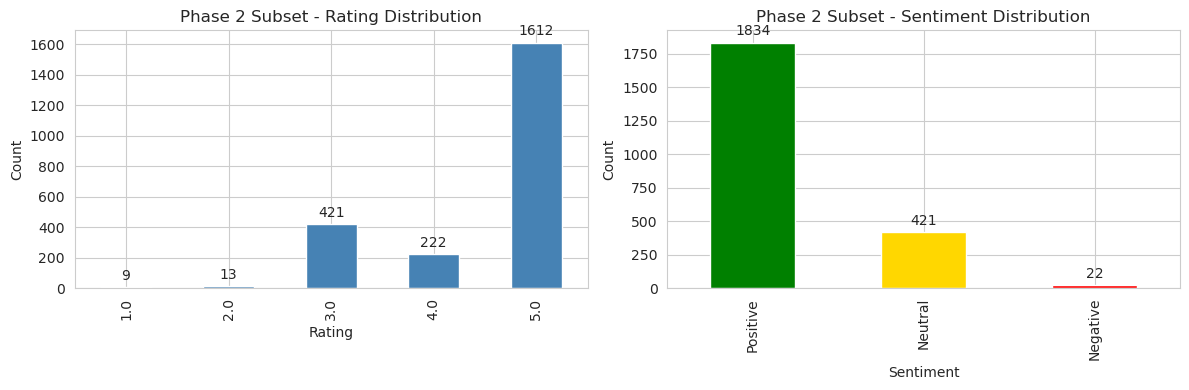

In [12]:
# Visualize rating and sentiment distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
df_phase2["overall"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Phase 2 Subset - Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0], label_type="edge", padding=3)

# Sentiment distribution
sentiment_order = ["Positive", "Neutral", "Negative"]
df_phase2["sentiment"].value_counts().reindex(sentiment_order).plot(
    kind="bar",
    color=["green", "gold", "red"],
    ax=axes[1]
)
axes[1].set_title("Phase 2 Subset - Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].bar_label(axes[1].containers[0], label_type="edge", padding=3)

plt.tight_layout()
plt.savefig("outputs/phase2_rating_sentiment_distribution.png", dpi=150)
plt.show()


--- REVIEW LENGTH (CHARACTERS) ---
count    2277.000000
mean     1481.945103
std       848.284016
min         2.000000
25%       971.000000
50%      1198.000000
75%      1864.000000
max      3932.000000
Name: review_length_chars, dtype: float64

--- REVIEW LENGTH (WORDS) ---
count    2277.000000
mean      287.505929
std       161.640463
min         1.000000
25%       188.000000
50%       242.000000
75%       371.000000
max       650.000000
Name: review_length_words, dtype: float64

--- OUTLIER ANALYSIS (IQR ON WORD COUNT) ---
Lower bound: -86.50
Upper bound: 645.50
Number of outlier reviews: 208

Duplicate reviews (same reviewerID, asin, reviewText): 2074


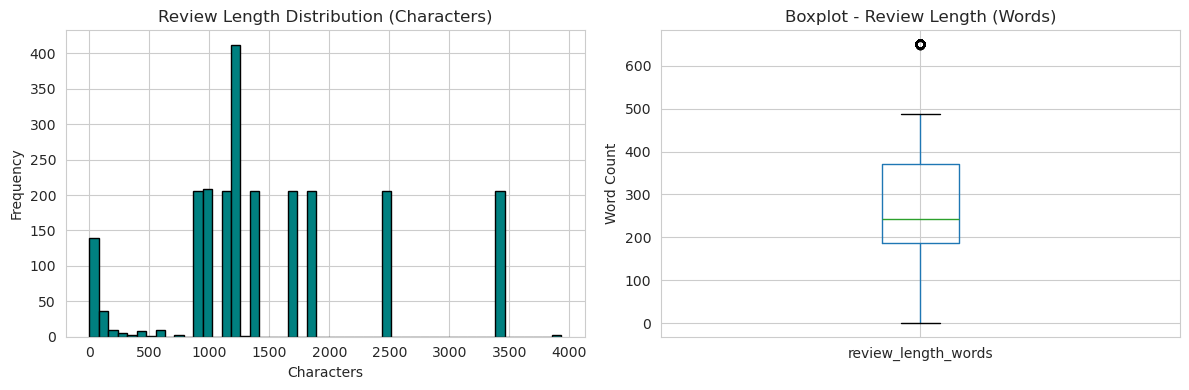

In [13]:
# Review length analysis, outliers, and duplicates

# Fill missing review text before length calculations
df_phase2["reviewText"] = df_phase2["reviewText"].fillna("")
df_phase2["summary"] = df_phase2["summary"].fillna("")

# Create review length features
df_phase2["review_length_chars"] = df_phase2["reviewText"].apply(len)
df_phase2["review_length_words"] = df_phase2["reviewText"].apply(lambda x: len(x.split()))

print("\n--- REVIEW LENGTH (CHARACTERS) ---")
print(df_phase2["review_length_chars"].describe())

print("\n--- REVIEW LENGTH (WORDS) ---")
print(df_phase2["review_length_words"].describe())

# Outlier detection using IQR on word count
q1 = df_phase2["review_length_words"].quantile(0.25)
q3 = df_phase2["review_length_words"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_phase2[
    (df_phase2["review_length_words"] < lower_bound) |
    (df_phase2["review_length_words"] > upper_bound)
]

print(f"\n--- OUTLIER ANALYSIS (IQR ON WORD COUNT) ---")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outlier reviews: {len(outliers)}")

# Duplicate check
duplicate_count = df_phase2.duplicated(subset=["reviewerID", "asin", "reviewText"]).sum()
print(f"\nDuplicate reviews (same reviewerID, asin, reviewText): {duplicate_count}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_phase2["review_length_chars"].hist(bins=50, color="teal", edgecolor="black", ax=axes[0])
axes[0].set_title("Review Length Distribution (Characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

df_phase2.boxplot(column="review_length_words", ax=axes[1])
axes[1].set_title("Boxplot - Review Length (Words)")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig("outputs/phase2_review_length_analysis.png", dpi=150)
plt.show()

In [14]:
# Select relevant columns and clean the subset

COLUMNS_USED = [
    "reviewerID",
    "asin",
    "overall",
    "summary",
    "reviewText",
    "sentiment",
    "review_length_chars",
    "review_length_words",
]

df_phase2 = df_phase2[[c for c in COLUMNS_USED if c in df_phase2.columns]].copy()

# Remove exact duplicates
df_phase2 = df_phase2.drop_duplicates(subset=["reviewerID", "asin", "reviewText"]).reset_index(drop=True)

# Combine summary and full review into one text field for richer sentiment information
df_phase2["full_review"] = (
    df_phase2["summary"].fillna("").str.strip() + " " +
    df_phase2["reviewText"].fillna("").str.strip()
).str.strip()

# Remove empty combined texts
empty_reviews = (df_phase2["full_review"].str.strip() == "").sum()
print(f"Empty combined reviews before removal: {empty_reviews}")

df_phase2 = df_phase2[df_phase2["full_review"].str.strip() != ""].reset_index(drop=True)

print(f"Dataset shape after column selection and cleaning: {df_phase2.shape}")
print(f"Columns selected:\n{df_phase2.columns.tolist()}")

Empty combined reviews before removal: 0
Dataset shape after column selection and cleaning: (203, 9)
Columns selected:
['reviewerID', 'asin', 'overall', 'summary', 'reviewText', 'sentiment', 'review_length_chars', 'review_length_words', 'full_review']


In [15]:
# Text pre-processing for machine learning
# Normalize text for TF-IDF + Multinomial Naive Bayes

lemmatizer = WordNetLemmatizer()

# Keep negation words because they matter for sentiment
stop_words = set(stopwords.words("english"))
stop_words = stop_words - {"no", "not", "nor"}

def preprocess_for_ml(text):
    """
    Clean text for machine learning:
    - lowercase
    - remove URLs and HTML
    - remove punctuation and numbers
    - tokenize
    - remove stop words
    - lemmatize
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)     # remove URLs
    text = re.sub(r"<.*?>", "", text)              # remove HTML tags
    text = re.sub(r"\d+", " ", text)               # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation

    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha() and token not in stop_words and len(token) > 1
    ]

    return " ".join(tokens)

df_phase2["text_ml"] = df_phase2["full_review"].apply(preprocess_for_ml)

# Remove rows that became empty after preprocessing
empty_after_preprocessing = (df_phase2["text_ml"].str.strip() == "").sum()
print(f"Rows empty after ML preprocessing: {empty_after_preprocessing}")

df_phase2 = df_phase2[df_phase2["text_ml"].str.strip() != ""].reset_index(drop=True)

print("\nSample of original vs preprocessed text:")
display(df_phase2[["full_review", "text_ml"]].head(5))

Rows empty after ML preprocessing: 0

Sample of original vs preprocessed text:


,full_review,text_ml
0,Great product I like this as a vent as well as...,great product like vent well something keep ho...
1,Five Stars good item,five star good item
2,Five Stars Fit my new LG dryer perfectly.,five star fit new lg dryer perfectly
3,Perfect size Good value for electric dryers,perfect size good value electric dryer
4,Five Stars Price and delivery was excellent.,five star price delivery excellent


In [16]:
# TF-IDF text representation and stratified split

X = df_phase2["text_ml"]
y = df_phase2["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size : {len(X_test)}")

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set size: 142
Testing set size : 61

Training label distribution:
sentiment
Positive    0.8803
Negative    0.0775
Neutral     0.0423
Name: proportion, dtype: float64

Testing label distribution:
sentiment
Positive    0.8689
Negative    0.0820
Neutral     0.0492
Name: proportion, dtype: float64


In [17]:
# Train and fine-tune Multinomial Naive Bayes

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.90, 0.95],
    "nb__alpha": [0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_nb_model = grid_search.best_estimator_

print("Best parameters found:")
print(grid_search.best_params_)

print(f"\nBest cross-validation weighted F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:
{'nb__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best cross-validation weighted F1: 0.8754



===== MULTINOMIAL NAIVE BAYES - CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Positive       0.95      1.00      0.97        53
     Neutral       1.00      0.67      0.80         3
    Negative       1.00      0.60      0.75         5

    accuracy                           0.95        61
   macro avg       0.98      0.76      0.84        61
weighted avg       0.95      0.95      0.95        61


===== TEST METRICS =====
Accuracy            : 0.9508
Precision (weighted): 0.9535
Recall (weighted)   : 0.9508
F1 Score (weighted) : 0.9458


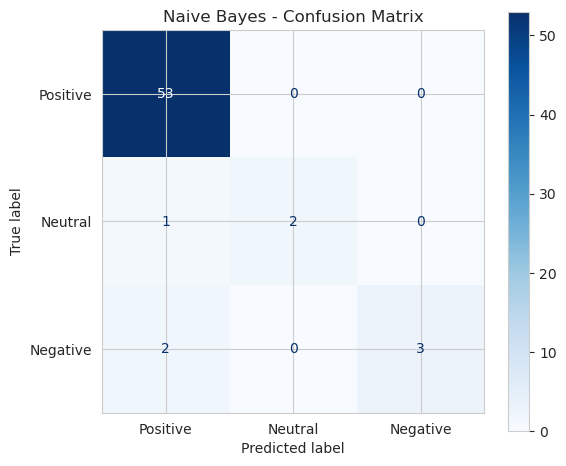


Files saved:
- outputs/phase2_nb_confusion_matrix.png
- outputs/phase2_naive_bayes_predictions.csv
- outputs/phase2_naive_bayes_metrics.csv


In [18]:
# Report accuracy, precision, recall, confusion matrix, and F1 score

labels = ["Positive", "Neutral", "Negative"]

y_pred = best_nb_model.predict(X_test)

print("\n===== MULTINOMIAL NAIVE BAYES - CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, labels=labels, target_names=labels, zero_division=0))

nb_accuracy = accuracy_score(y_test, y_pred)
nb_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
nb_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
nb_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n===== TEST METRICS =====")
print(f"Accuracy            : {nb_accuracy:.4f}")
print(f"Precision (weighted): {nb_precision:.4f}")
print(f"Recall (weighted)   : {nb_recall:.4f}")
print(f"F1 Score (weighted) : {nb_f1:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(ax=ax, cmap="Blues")
ax.set_title("Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/phase2_nb_confusion_matrix.png", dpi=150)
plt.show()

# Save detailed predictions
results_df = pd.DataFrame({
    "text_ml": X_test.values,
    "actual_sentiment": y_test.values,
    "predicted_sentiment": y_pred
})

results_df.to_csv("outputs/phase2_naive_bayes_predictions.csv", index=False)

# Save summary metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 Score (weighted)"],
    "Naive_Bayes": [nb_accuracy, nb_precision, nb_recall, nb_f1]
})

metrics_df.to_csv("outputs/phase2_naive_bayes_metrics.csv", index=False)

print("\nFiles saved:")
print("- outputs/phase2_nb_confusion_matrix.png")
print("- outputs/phase2_naive_bayes_predictions.csv")
print("- outputs/phase2_naive_bayes_metrics.csv")